In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

from rasterio.features import rasterize
from rasterio.transform import from_bounds
from shapely.validation import make_valid

from config import *

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
USSF_filepath = geospat_data_filepath+"conus_state_shp/cb_2017_us_state_5m.shp"

In [3]:
# Reading and filtering 
basinatlas = pd.read_csv(basin_atlas_filepath+"static_catchment_characteristics.csv")
basinatlas = basinatlas[['STREAM_ID',
                         'clz_cl_smj', # Climate Zones (spatial maj)
                         'ari_ix_sav', # Aridity Index (spatial ave)
                         'kar_pc_sse', # Karst percentage (spatial extent %)
                         'ppd_pk_sav', # Pop density (pop km2; spatial ave)
                         'rdd_mk_sav', # Road Density (spatial ave)
                         'hft_ix_s09', # Human footprint (2009)
                         'slp_dg_sav', # Terrain slope
                         'lit_cl_smj', # Lith classes (spatial maj)
                         'ele_mt_sav'  # Average elevation
                        ]]

param_pretty = {'clz_cl_smj_remap':'Climate Zones',
              'ari_ix_sav':'Aridity Index',
              'kar_pc_sse':'% Karst', 
              'ppd_pk_sav':'Pop. Density',
              'rdd_mk_sav':'Road Density',
              'hft_ix_s09':'Human footprint',
              'slp_dg_sav':'Terrain slope',
              'lit_cl_smj_remap':'Lithology classes',
              'ele_mt_sav':'Average elevation'}

solute_pretty = {"WTemp_C":"Temp (°C)",
                "SpC_uScm":"SpC (µS/cm)",
                "DO_mgL":"DO (mg/L)",
                "pH":"pH",
                "Turb_FNU":"Turbidity (FNU)",
                "Turb_NTU":"Turbidity (NTU)",
                "NO3_mgNL":"NO₃-N (mg/L)",
                "fDOM_QSU":"fDOM (QSU)",
                "fDOM_RFU":"fDOM (RFU)",
                "DOC_mgL":"DOC (mg/L)",
                "PO4_mgL":"PO₄ (mg/L)",
                "Chla_ugL":"Chl-a (µg/L)",
                "Chla_RFU":"Chl-a (RFU)",
                "PC_ugL":"PC (µg/L)",
                "PC_RFU":"PC (RFU)",
               }

# Converting to true values
basinatlas['ari_ix_sav'] = basinatlas['ari_ix_sav']/100
basinatlas['slp_dg_sav'] = basinatlas['slp_dg_sav']/10
basinatlas.head(2)

,STREAM_ID,clz_cl_smj,ari_ix_sav,kar_pc_sse,ppd_pk_sav,rdd_mk_sav,hft_ix_s09,slp_dg_sav,lit_cl_smj,ele_mt_sav
0,STREAM-gauge-3400,10,1.188426,0.000000,851.284352,7093.406211,366.916319,2.282002,3,89.330434
1,STREAM-gauge-2912,10,0.931122,57.681377,308.801413,2318.609959,218.206417,0.520587,6,217.631878


In [4]:
# Mapping cateogorical variables
clz_cl = pd.read_csv(basin_atlas_filepath+'clz_cl.csv')
clz_cl_dict = pd.Series(clz_cl.Reclassification.values, index=clz_cl.GEnZ_ID).to_dict()

lit_cl = pd.read_csv(basin_atlas_filepath+'lit_cl.csv')
lit_cl_dict = pd.Series(lit_cl.Reclassification.values, index=lit_cl.GLiM_ID).to_dict()

basinatlas['clz_cl_smj_remap'] = basinatlas['clz_cl_smj'].map(clz_cl_dict)
basinatlas['lit_cl_smj_remap'] = basinatlas['lit_cl_smj'].map(lit_cl_dict)
basinatlas.head(2)

,STREAM_ID,clz_cl_smj,ari_ix_sav,kar_pc_sse,ppd_pk_sav,rdd_mk_sav,hft_ix_s09,slp_dg_sav,lit_cl_smj,ele_mt_sav,clz_cl_smj_remap,lit_cl_smj_remap
0,STREAM-gauge-3400,10,1.188426,0.000000,851.284352,7093.406211,366.916319,2.282002,3,89.330434,6,Sedimentary
1,STREAM-gauge-2912,10,0.931122,57.681377,308.801413,2318.609959,218.206417,0.520587,6,217.631878,6,Carbonate


In [5]:
# Processing metadata, isolating specific parameters
md_wide = pd.read_csv(metadata_filepath+"metadata.csv", dtype = {'sourceID': str})
print(f"Full dataset size: {md_wide.shape[0]}")
params = ['SpC_uScm','DO_mgL','Turb_FNU']

for param in params:
    md_wide[param] = md_wide['WQ_parameters'].str.contains(param)

# Removing the stations without data
md_wide = md_wide[(md_wide['SpC_uScm']) | (md_wide['DO_mgL']) | (md_wide['Turb_FNU'])]
print(f"Filtered dataset size: {md_wide.shape[0]}")

Full dataset size: 4268
Filtered dataset size: 2688


In [6]:
md = md_wide.melt(
    id_vars=['STREAM_ID', 'sourceID', 'source', 'site_name', 'latitude_wgs84', 
             'longitude_wgs84', 'catchmentarea_km2', 'state_name', 'time_zone', 'WQ_parameters'],
    value_vars=['SpC_uScm', 'DO_mgL', 'Turb_FNU'],
    var_name='parameter',
    value_name='has_data'
)
md = md[md['has_data']].drop(['WQ_parameters','has_data'],axis=1)
md.sort_values('STREAM_ID').head()
md.size

50220

In [7]:
#md_spatial_data = md.merge(basinatlas, on='STREAM_ID')
md_spatial_data = md.merge(basinatlas, on='STREAM_ID', how='left') # this conserves the stations that are not found in BasinAtlas yet
md_spatial_data.head()
md_spatial_data.size
#md_spatial_data.to_csv('../OUTPUT/filtered_spC_DO_turb_basinparams.csv')

105462

In [8]:
# Merging the temporal data derived by Sai
temporal_summary_long = pd.read_csv(OUTPUT_filepath+"temporal_statistics.csv")
temporal_summary_long.head()

,STREAM_ID,parameter,pct_missing,length_hr,longest_hr,actual_hr,pct_missing_01,pct_missing_02,pct_missing_03,pct_missing_04,pct_missing_05,pct_missing_06,pct_missing_07,pct_missing_08,pct_missing_09,pct_missing_10,pct_missing_11,pct_missing_12
0,STREAM-gauge-1,WTemp_C,1.22,68292.0,10346.0,67458.0,0.00,0.00,0.00,0.0,0.0,0.0,0.07,0.0,0.0,0.0,0.00,0.00
1,STREAM-gauge-100,WTemp_C,1.28,13104.0,4702.0,12936.0,4.44,0.00,0.27,0.0,0.0,1.6,0.00,0.0,0.0,0.0,0.00,14.52
2,STREAM-gauge-1000,WTemp_C,0.00,8785.0,8785.0,8785.0,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.00
3,STREAM-gauge-1001,WTemp_C,0.00,8785.0,8785.0,8785.0,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.00
4,STREAM-gauge-1002,WTemp_C,5.55,8785.0,4548.0,8297.0,36.16,22.56,0.81,0.0,0.0,0.0,0.00,0.0,0.0,0.0,1.25,6.32


In [9]:
md_data = md_spatial_data.merge(temporal_summary_long, on=['STREAM_ID','parameter'])
md_data.to_csv('../OUTPUT/filtered_spC_DO_turb_basinparams_tempstats.csv')
md_data.head()

,STREAM_ID,sourceID,source,site_name,latitude_wgs84,longitude_wgs84,catchmentarea_km2,state_name,time_zone,parameter,clz_cl_smj,ari_ix_sav,kar_pc_sse,ppd_pk_sav,rdd_mk_sav,hft_ix_s09,slp_dg_sav,lit_cl_smj,ele_mt_sav,clz_cl_smj_remap,lit_cl_smj_remap,pct_missing,length_hr,longest_hr,actual_hr,pct_missing_01,pct_missing_02,pct_missing_03,pct_missing_04,pct_missing_05,pct_missing_06,pct_missing_07,pct_missing_08,pct_missing_09,pct_missing_10,pct_missing_11,pct_missing_12
0,STREAM-gauge-4,02480212,USGS,"PASCAGOULA RIVER AT MI 1 AT PASCAGOULA, MS",30.367778,-88.563056,24667.789852,Mississippi,Central,SpC_uScm,14,1.060956,9.961736,24.374596,298.638130,88.883001,1.303798,1,87.876990,8,Uncons. Sedi.,6.16,138279.0,11428.0,129761.0,0.13,0.15,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.20,0.00,0.00
1,STREAM-gauge-5,02480285,USGS,"WEST PASCAGOULA RIVER AT HWY 90 AT GAUTIER, MS",30.382694,-88.608444,24674.400584,Mississippi,Central,SpC_uScm,14,1.061011,9.959067,24.392870,300.241186,88.929804,1.303614,1,87.855498,8,Uncons. Sedi.,6.11,138304.0,9600.0,129847.0,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,1.01,0.00,0.07
2,STREAM-gauge-21,07288048,USGS,"RICHIES BAYOU AT SHERARD, MS",34.209222,-90.700194,83.839065,Mississippi,Central,SpC_uScm,11,1.029800,0.000000,5.727280,318.385966,63.076764,0.205583,1,49.979666,7,Uncons. Sedi.,84.46,129728.0,3529.0,20160.0,100.00,100.00,100.00,100.00,100.00,100.00,100.0,100.00,100.00,100.00,100.00,100.00
3,STREAM-gauge-22,07288068,USGS,"HARRIS BAYOU AT PALMER RD EAST OF ALLIGATOR, MS",34.074750,-90.624944,173.993771,Mississippi,Central,SpC_uScm,11,1.028184,0.000000,7.139389,286.227477,68.359460,0.164934,1,48.687893,7,Uncons. Sedi.,17.90,26556.0,2159.0,21803.0,3.49,0.22,74.73,10.28,28.36,73.89,0.0,0.27,0.14,9.95,0.14,0.00
4,STREAM-gauge-24,07288500,USGS,"BIG SUNFLOWER RIVER AT SUNFLOWER, MS",33.547356,-90.543158,1978.983031,Mississippi,Central,SpC_uScm,11,1.032139,0.000000,19.371568,277.412850,86.687516,0.073505,1,44.513774,7,Uncons. Sedi.,84.90,143722.0,4149.0,21709.0,100.00,100.00,100.00,100.00,100.00,100.00,100.0,100.00,100.00,100.00,100.00,100.00


In [10]:
md_gdf = gpd.GeoDataFrame(md_data, 
                          geometry=gpd.points_from_xy(md_data.longitude_wgs84, md_data.latitude_wgs84), 
                          crs="EPSG:4326")
md_gdf.head(2)

,STREAM_ID,sourceID,source,site_name,latitude_wgs84,longitude_wgs84,catchmentarea_km2,state_name,time_zone,parameter,clz_cl_smj,ari_ix_sav,kar_pc_sse,ppd_pk_sav,rdd_mk_sav,hft_ix_s09,slp_dg_sav,lit_cl_smj,ele_mt_sav,clz_cl_smj_remap,lit_cl_smj_remap,pct_missing,length_hr,longest_hr,actual_hr,pct_missing_01,pct_missing_02,pct_missing_03,pct_missing_04,pct_missing_05,pct_missing_06,pct_missing_07,pct_missing_08,pct_missing_09,pct_missing_10,pct_missing_11,pct_missing_12,geometry
0,STREAM-gauge-4,02480212,USGS,"PASCAGOULA RIVER AT MI 1 AT PASCAGOULA, MS",30.367778,-88.563056,24667.789852,Mississippi,Central,SpC_uScm,14,1.060956,9.961736,24.374596,298.638130,88.883001,1.303798,1,87.876990,8,Uncons. Sedi.,6.16,138279.0,11428.0,129761.0,0.13,0.15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.20,0.0,0.00,POINT (-88.56306 30.36778)
1,STREAM-gauge-5,02480285,USGS,"WEST PASCAGOULA RIVER AT HWY 90 AT GAUTIER, MS",30.382694,-88.608444,24674.400584,Mississippi,Central,SpC_uScm,14,1.061011,9.959067,24.392870,300.241186,88.929804,1.303614,1,87.855498,8,Uncons. Sedi.,6.11,138304.0,9600.0,129847.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.01,0.0,0.07,POINT (-88.60844 30.38269)


## Exploring spatial patterns 

In [11]:
HUC8_properties = pd.read_csv(basin_atlas_filepath+'huc8_basinatlas_properties.csv',dtype={"HUC8": str})
#huc8 = gpd.read_file(geospat_data_filepath+'huc8_shapefiles/HUC8_US_5070.shp')
#HUC8_properties = HUC8_properties.merge(huc8, on='HUC8')
HUC8_properties.head(2)

,HUC8,ari_ix_sav,kar_pc_sse,ppd_pk_sav,rdd_mk_sav,hft_ix_s09,slp_dg_sav,ele_mt_sav,clz_cl_smj,lit_cl_smj
0,01010002,1.317808,0.000000,0.022995,0.330676,3.376635,3.696777,364.239887,7,3
1,01010003,1.288682,0.012406,3.398320,59.319011,30.739143,4.195638,276.806660,7,3


In [12]:
HUC8_properties['clz_cl_smj_remap'] = HUC8_properties['clz_cl_smj'].map(clz_cl_dict)
HUC8_properties['lit_cl_smj_remap'] = HUC8_properties['lit_cl_smj'].map(lit_cl_dict)
HUC8_properties.head(2)

,HUC8,ari_ix_sav,kar_pc_sse,ppd_pk_sav,rdd_mk_sav,hft_ix_s09,slp_dg_sav,ele_mt_sav,clz_cl_smj,lit_cl_smj,clz_cl_smj_remap,lit_cl_smj_remap
0,01010002,1.317808,0.000000,0.022995,0.330676,3.376635,3.696777,364.239887,7,3,5,Sedimentary
1,01010003,1.288682,0.012406,3.398320,59.319011,30.739143,4.195638,276.806660,7,3,5,Sedimentary


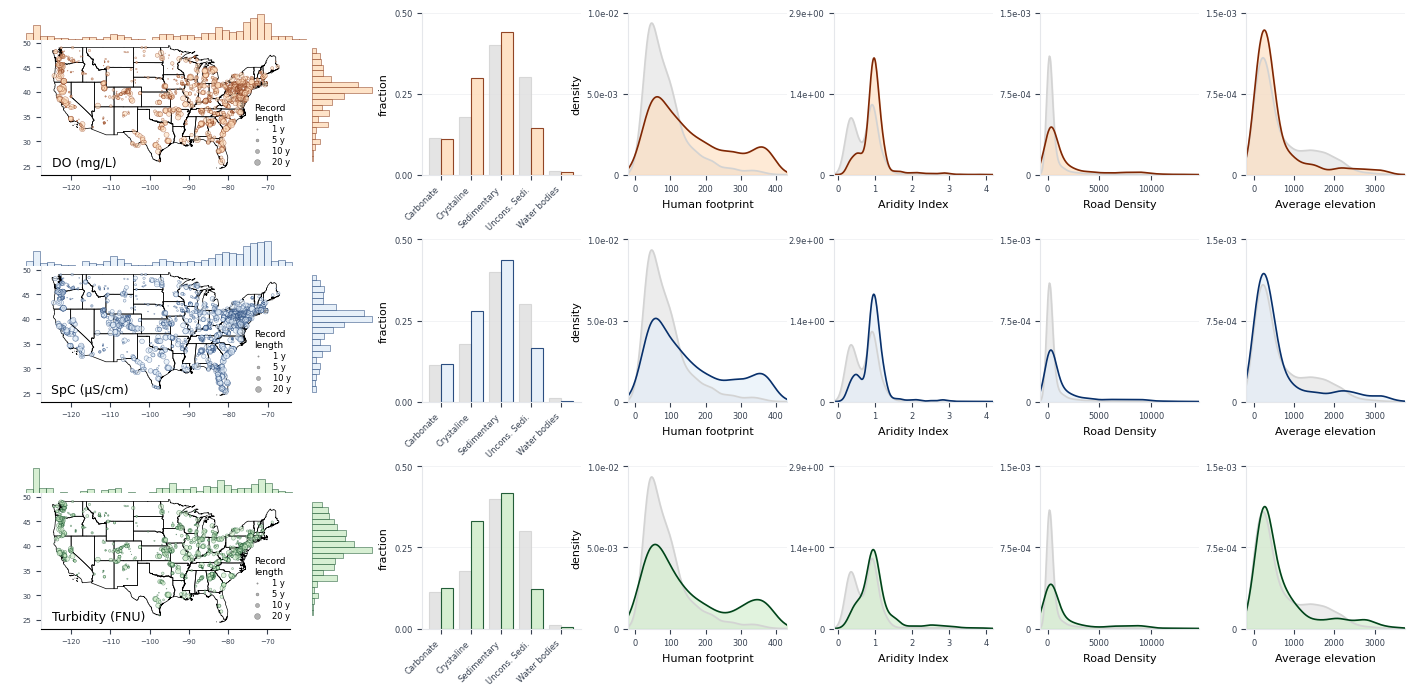

In [13]:
# Anxillary files and info
US_shp = gpd.read_file(USSF_filepath)

# Colour pallette
MAP_COLOR = '#2563EB'
HIST_COLOR = '#80cdc1'
HIST_EDGE = '#018571'
BG_COLOR = '#FFFFFF'
GRID_COLOR = '#E5E7EB'

# setting properties
shared_ylims = {
    'lit_cl_smj_remap': 0.5,
    'hft_ix_s09': 0.01,
    'ari_ix_sav': 2.9,
    'rdd_mk_sav': 0.0015,
    'ele_mt_sav': 0.0015
}

PARAM_COLORS = {
    'DO_mgL':    {'fill': '#FEDCBB', 'edge': '#7F2704'},
    'SpC_uScm':  {'fill': '#E2EDF8', 'edge': '#08306B'},
    'Turb_FNU':  {'fill': '#CEECC8', 'edge': '#00431A'},
}

params =  {"DO_mgL":"DO (mg/L)",
            "SpC_uScm":"SpC (µS/cm)",
            "Turb_FNU":"Turbidity (FNU)"}
               

vars_cat = ['lit_cl_smj_remap']
vars_cont = ['hft_ix_s09', 'ari_ix_sav', 'rdd_mk_sav', 'ele_mt_sav']

# Shared x-axis limits for histograms
shared_xlims = {}
for var in vars_cont:
    global_min = md_gdf[var].min()
    global_max = md_gdf[var].max()
    margin = (global_max - global_min) * 0.05
    shared_xlims[var] = (global_min - margin, global_max + margin)
    
# Create gridspec: map with marginal histograms + bar + 4 histograms
fig = plt.figure(figsize=(18, 8))
gs = fig.add_gridspec(3, 7, hspace=0.4, wspace=0.3)

for j, (param_col, param_label) in enumerate(params.items()):

    fill_color = PARAM_COLORS[param_col]['fill']
    edge_color = PARAM_COLORS[param_col]['edge']
    md_gdf_filt = md_gdf[md_gdf['parameter'] == param_col]

    # --- Map with marginal distributions ---
    # Sub-gridspec for map cell (top-left)
    gs_map = gs[j, 0:2].subgridspec(2, 2, width_ratios=[5, 1], height_ratios=[1, 5],
                                 hspace=0, wspace=-0.05)
    gs_map 
    ax_map = fig.add_subplot(gs_map[1, 0])
    ax_top = fig.add_subplot(gs_map[0, 0], sharex=ax_map)
    ax_right = fig.add_subplot(gs_map[1, 1], sharey=ax_map)

    # Main map
    US_shp.plot(ax=ax_map, facecolor='none', edgecolor='black', linewidth=0.5)
    md_gdf_filt.plot(ax=ax_map,
                     color=fill_color, 
                     markersize=md_gdf_filt['actual_hr'] / 10000,
                     alpha=0.6, 
                     edgecolor=edge_color, 
                     linewidth=0.3)
    ax_map.tick_params(labelsize=5, colors='#374151')
    ax_map.spines[['top', 'right']].set_visible(False)
    ax_map.spines[['top', 'left']].set_color(GRID_COLOR)
    ax_map.text(-125, 25, param_label, fontsize=9)

    # Bubble size legend (only on first row)
    legend_handles = []
    if j == 0:
        legend_values = [8766, 43830, 87656, 175320]  # 1 year, 5 years, 10 year
        
    for val in legend_values:
        handle = ax_map.scatter([], [], s=val / 10000, color='gray',
                                edgecolor='#333', linewidth=0.3, alpha=0.6,
                                label=f'{val / 24 / 365:.0f} y')
        legend_handles.append(handle)
    
    ax_map.legend(
        handles=legend_handles,
        title='Record\nlength',
        fontsize=6,
        title_fontsize=6.5,
        loc='lower left',
        bbox_to_anchor=(0.80, 0),
        frameon=False,
        labelspacing=0.25,
        borderpad=0.5,
    )

    # Longitude distribution (top)
    lons = md_gdf_filt.geometry.x
    lats = md_gdf_filt.geometry.y
    ax_top.hist(lons, bins=40, color=fill_color, edgecolor=edge_color, linewidth=0.4, alpha=0.8)
    ax_top.tick_params(labelbottom=False, labelleft=False, left=False, bottom=False)
    ax_top.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

    # Latitude distribution (right)
    ax_right.hist(lats, bins=20, orientation='horizontal',
                  color=fill_color, edgecolor=edge_color, linewidth=0.4, alpha=0.8)
    ax_right.tick_params(labelbottom=False, labelleft=False, left=False, bottom=False)
    ax_right.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

    # --- Bar chart ---
    cntr = 1
    ax_bar = fig.add_subplot(gs[j, 2])
    for i, var in enumerate(vars_cat):
        cntr += 1
        stream_counts = md_gdf_filt[var].value_counts().sort_index()
        huc8_counts = HUC8_properties[var].value_counts().sort_index()
        
        # union of categories so both series align
        cats = sorted(set(huc8_counts.index) | set(stream_counts.index))
        huc8_frac = np.array([huc8_counts.get(c, 0) for c in cats], dtype=float)
        stream_frac = np.array([stream_counts.get(c, 0) for c in cats], dtype=float)
        huc8_frac /= huc8_frac.sum()
        stream_frac /= stream_frac.sum()
        
        x = np.arange(len(cats))
        w = 0.4

        # plotting the histograms next to eachother
        ax_bar.bar(x - w/2, huc8_frac, width=w,
                   color='#E0E0E0', edgecolor='#d3d3d3', linewidth=0.8, alpha=0.85, label='HUC8')
        ax_bar.bar(x + w/2, stream_frac, width=w,
                   color=fill_color, edgecolor=edge_color, linewidth=0.8, alpha=0.85, label='STREAM')
        # aesthetic
        ax_bar.set_xticks(x)
        ax_bar.set_xticklabels(cats, rotation=45, ha='right')
        
        ax_bar.set_ylabel('fraction', fontsize=8)
        ax_bar.set_ylim(0, shared_ylims[var])
        ax_bar.set_yticks([0, shared_ylims[var]/2, shared_ylims[var]])
        
        ax_bar.set_facecolor(BG_COLOR)
        ax_bar.spines[['top', 'right']].set_visible(False)
        ax_bar.spines[['left', 'bottom']].set_color(GRID_COLOR)
        ax_bar.tick_params(colors='#374151', labelsize=6)
        ax_bar.yaxis.grid(True, color=GRID_COLOR, linewidth=0.5, alpha=0.7)
        ax_bar.set_axisbelow(True)
        #ax_bar.tick_params(axis='x', rotation=45)

    # --- Histograms (remaining slots) ---
    hist_positions = [(j, 3), (j, 4), (j, 5), (j, 6)]
    for i, var in enumerate(vars_cont):
        row, col = hist_positions[i]
        a = fig.add_subplot(gs[row, col])
    
        # HUC8 distribution
        data = HUC8_properties[var].dropna()
        kde = gaussian_kde(data)
        x_range = np.linspace(shared_xlims[var][0], shared_xlims[var][1], 300)
        a.fill_between(x_range, kde(x_range), color='#E0E0E0', alpha=0.6)
        a.plot(x_range, kde(x_range), color='#d3d3d3', linewidth=1.2)
    
        # STREAM watershed distribution
        data = md_gdf_filt[var].dropna()
        kde = gaussian_kde(data)
        x_range = np.linspace(shared_xlims[var][0], shared_xlims[var][1], 300)
        a.fill_between(x_range, kde(x_range), color=fill_color, alpha=0.6)
        a.plot(x_range, kde(x_range), color=edge_color, linewidth=1.2)
    
        # styling
        a.set_xlim(shared_xlims[var])
        a.set_xlabel(param_pretty[var], fontsize=8)
        a.set_facecolor(BG_COLOR)
        a.spines[['top', 'right']].set_visible(False)
        a.spines[['left', 'bottom']].set_color(GRID_COLOR)
        a.tick_params(colors='#374151', labelsize=6)
        a.yaxis.grid(True, color=GRID_COLOR, linewidth=0.5, alpha=0.7)
        a.set_axisbelow(True)
        if i == 0:
            a.set_ylabel('density', fontsize=8)
        a.set_ylim(0, shared_ylims[var])
        a.set_yticks([0, shared_ylims[var]/2, shared_ylims[var]])
        a.set_yticklabels(['0', f'{shared_ylims[var]/2:.1e}', f'{shared_ylims[var]:.1e}'], fontsize=6)
        
plt.savefig(f'../OUTPUT/spatial_patterns/parameter_spatial_distributions.png', dpi=600, bbox_inches='tight')

# Path length analysis

In [14]:
# !! There is one STREAM station without a comid. 
comid_pl = pd.read_csv(ancillary_data_filepath+"geomorph_data/nhdplus_pathlength.csv")
comid_pl.head(2)

,STREAM_ID,reachcode,comid,pathlength
0,STREAM-gauge-1723,5.010001e+12,8972788,3603
1,STREAM-gauge-2691,5.010001e+12,8969860,3506


In [15]:
# Attaching comid and path length to metadata
md_data = md_data.merge(comid_pl)
md_data.head()

,STREAM_ID,sourceID,source,site_name,latitude_wgs84,longitude_wgs84,catchmentarea_km2,state_name,time_zone,parameter,clz_cl_smj,ari_ix_sav,kar_pc_sse,ppd_pk_sav,rdd_mk_sav,hft_ix_s09,slp_dg_sav,lit_cl_smj,ele_mt_sav,clz_cl_smj_remap,lit_cl_smj_remap,pct_missing,length_hr,longest_hr,actual_hr,pct_missing_01,pct_missing_02,pct_missing_03,pct_missing_04,pct_missing_05,pct_missing_06,pct_missing_07,pct_missing_08,pct_missing_09,pct_missing_10,pct_missing_11,pct_missing_12,reachcode,comid,pathlength
0,STREAM-gauge-21,07288048,USGS,"RICHIES BAYOU AT SHERARD, MS",34.209222,-90.700194,83.839065,Mississippi,Central,SpC_uScm,11,1.029800,0.0,5.727280,318.385966,63.076764,0.205583,1,49.979666,7,Uncons. Sedi.,84.46,129728.0,3529.0,20160.0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,8.030207e+12,17951791,1130
1,STREAM-gauge-22,07288068,USGS,"HARRIS BAYOU AT PALMER RD EAST OF ALLIGATOR, MS",34.074750,-90.624944,173.993771,Mississippi,Central,SpC_uScm,11,1.028184,0.0,7.139389,286.227477,68.359460,0.164934,1,48.687893,7,Uncons. Sedi.,17.90,26556.0,2159.0,21803.0,3.49,0.22,74.73,10.28,28.36,73.89,0.00,0.27,0.14,9.95,0.14,0.00,8.030207e+12,17952389,1106
2,STREAM-gauge-24,07288500,USGS,"BIG SUNFLOWER RIVER AT SUNFLOWER, MS",33.547356,-90.543158,1978.983031,Mississippi,Central,SpC_uScm,11,1.032139,0.0,19.371568,277.412850,86.687516,0.073505,1,44.513774,7,Uncons. Sedi.,84.90,143722.0,4149.0,21709.0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,8.030207e+12,17956869,984
3,STREAM-gauge-25,07288521,USGS,"PORTER BAYOU AT STEPHENSVILLE, MS",33.548250,-90.672361,267.047873,Mississippi,Central,SpC_uScm,14,1.035415,0.0,22.314837,385.516612,103.935798,0.066311,1,38.760889,8,Uncons. Sedi.,50.94,29590.0,1288.0,14516.0,8.20,39.16,52.82,38.47,56.92,20.90,18.15,100.00,100.00,95.56,19.58,2.02,8.030207e+12,17956783,976
4,STREAM-gauge-27,0728875070,USGS,"DEER CREEK EAST OF LELAND, MS",33.401111,-90.891944,239.504705,Mississippi,Central,SpC_uScm,14,1.000809,0.0,12.229427,212.950571,94.965579,0.156879,1,40.410802,8,Uncons. Sedi.,12.62,82716.0,8017.0,72280.0,0.00,0.00,0.00,0.14,0.00,0.14,0.00,0.13,0.14,1.28,0.35,0.07,8.030207e+12,17930376,922


DO_mgL: min=1.0000, max=25.0000
SpC_uScm: min=1.0000, max=33.0000
Turb_FNU: min=1.0000, max=19.0000


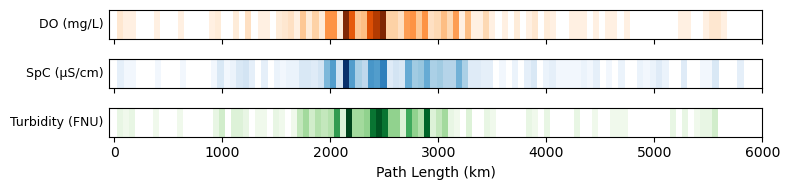

In [16]:
# network density map
fig, axes = plt.subplots(3, 1, figsize=(8, 2), sharex=True)
cmap_names = ['Oranges', 'Blues', 'Greens'] 

params = ['DO_mgL', 'SpC_uScm', 'Turb_FNU']
labels = ['DO (mg/L)', 'SpC (μS/cm)', 'Turbidity (FNU)']

for ax, param, label, cmap_name in zip(axes, params, labels, cmap_names):
    subset = md_data[md_data['parameter'] == param]['pathlength'].dropna()
    counts, bin_edges = np.histogram(subset, bins=100, density=True)
    
    cmap = plt.get_cmap(cmap_name)  # ← get the actual colormap object

    # Map colors: white where no data, colormap where data exists
    colors = np.array([cmap(c / counts.max()) if c > 0 else (1, 1, 1, 1) for c in counts])
    
    ax.bar(bin_edges[:-1], np.ones_like(counts), width=np.diff(bin_edges),
           color=colors,
           align='edge')
    
    ax.set_ylabel(label, fontsize=9, 
                  rotation=0, 
                  ha='right', 
                      verticalalignment='center')
    
    ax.set_yticks([])
    ax.set_xlim([-50, 6000])

axes[-1].set_xlabel("Path Length (km)")

plt.tight_layout()
plt.savefig(f'../OUTPUT/spatial_patterns/denstiy_network_length.png', dpi=600, bbox_inches='tight')

for param, cmap_name in zip(params, cmap_names):
    subset = md_data[md_data['parameter'] == param]['pathlength'].dropna()
    counts, bin_edges = np.histogram(subset, bins=100, density=False)
    print(f"{param}: min={counts[counts>0].min():.4f}, max={counts.max():.4f}")

## Density of sampled data at represented by headmap of watersehds

In [37]:
heatmaps

{}

In [41]:
# Heatmap of watersheds to better represent spatial distribution
cnt = 0
missing_sites = []
heatmaps = {} # dict for heatmap rasters
# Defining grod
raster_res = 0.01
bounds = US_shp.total_bounds # using US state shapfile for bounds
width = int((bounds[2] - bounds[0]) / raster_res)
height = int((bounds[3] - bounds[1]) / raster_res)
transform = from_bounds(*bounds, width, height)

for param in params:
    # Empty heatmap for each parameter
    heatmap = np.zeros((height, width), dtype='float32')
    md_data_i = md_data[md_data['parameter'] == param]
    for j, row in md_data_i.iterrows():
        site_id = row['STREAM_ID']
        try:
            wtshd = gpd.read_file(shapefile_filepath + site_id + '.shp')
            wtshd = wtshd.to_crs(US_shp.crs)
            geom = wtshd.geometry.iloc[0]
            if not geom.is_valid:
                geom = make_valid(geom)
            if geom.is_empty or not geom.is_valid:
                missing_sites.append(site_id)
                cnt += 1
                continue
            r = rasterize([(geom, 1)], out_shape=(height, width),
                          transform=transform, fill=0, dtype='uint8', all_touched=True)
            #heatmap += r
            heatmap += r * (row['actual_hr']/8766) # if you want to scale it by hours of data available
        except Exception as e:
            cnt += 1
            missing_sites.append(site_id)
            print(f"  {site_id}: {e}")
        heatmaps[param] = heatmap
    
    print(f'Error for {cnt} watersheds.')

Error for 0 watersheds.
Error for 0 watersheds.
Error for 0 watersheds.


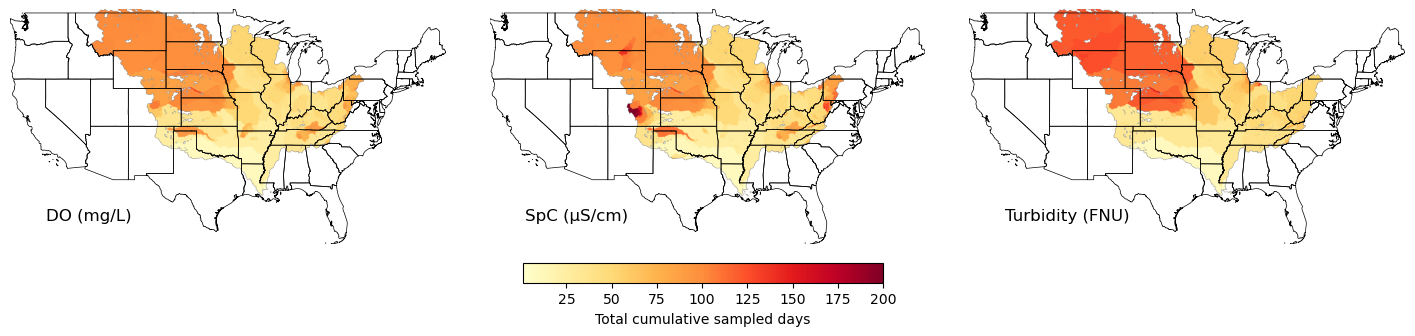

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for ax, param in zip(axes, params):
    heatmap_masked = np.ma.masked_where(heatmaps[param] == 0, heatmaps[param])
    cmap = plt.cm.YlOrRd
    cmap.set_bad(color='none')
    im = ax.imshow(heatmap_masked, extent=[bounds[0], bounds[2], bounds[1], bounds[3]], cmap=cmap, vmin=1, vmax=200)
    US_shp.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5)
    ax.text(-120, 27, solute_pretty[param], fontsize=12)
    ax.set_axis_off()

cbar_ax = fig.add_axes([0.41, 0.3, 0.2, 0.025])  # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, orientation='horizontal', label='Total cumulative sampled days')
fig.subplots_adjust(wspace=0.1)

#plt.tight_layout()
plt.savefig(f'../OUTPUT/spatial_patterns/heat_maps_density_of_data.png', dpi=600, bbox_inches='tight')